# Rating Scale Model (RSM) — Bayesian Estimation with Stan

## 1. Model Description

The **Rating Scale Model** (Andrich, 1978) is a constrained version of the PCM designed for **Likert-type rating scales** where all items share the same set of category threshold spacings.

### Category Probabilities

The RSM parameterises item step difficulties as:

$$\delta_{ik} = b_i + \tau_k$$

where $b_i$ is the **item location** (overall difficulty of item $i$) and $\tau_k$ is the **category threshold** shared across all items. The PCM log-odds become:

$$\log \frac{P(X_{ji} = k)}{P(X_{ji} = k-1)} = \theta_j - b_i - \tau_k, \quad k = 1, \ldots, K{-}1$$

Full category probabilities (divide-by-total form):

$$P(X_{ji} = k) \propto \exp\!\left(k(\theta_j - b_i) - \sum_{m=1}^{k} \tau_m\right)$$

| Parameter | Interpretation |
|-----------|----------------|
| $\theta_j$ | Person ability |
| $b_i$ | Item location (shifts item ICC left/right) |
| $\tau_k$ | Common category threshold (same for all items) |

### Key Properties
- **Parsimony**: Only $I + (K{-}1)$ free parameters (vs. $I \times (K{-}1)$ for PCM), making it ideal for short scales.
- The RSM assumes all items use the **same psychological response process** — appropriate when items share a single response scale.
- Identification: $\sum_k \tau_k = 0$ (sum-to-zero constraint on thresholds).

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad b_i \sim \mathcal{N}(0, 2), \quad \tau_k \sim \mathcal{N}(0, 2) \text{ (sum-to-zero)}$$

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

## 2. Synthetic Data Generation

77 students, 20 items, 4 categories. True thresholds $\tau_k$ are shared across all items.

In [2]:
J, I, K = 77, 20, 4

theta_true = np.random.normal(0, 1, J)
b_true     = np.random.normal(0, 1, I);  b_true -= b_true.mean()
# Common thresholds, sum = 0
tau_raw    = np.array([-1.2, 0.0, 1.2])   # 3 thresholds for K=4, centered
tau_true   = tau_raw - tau_raw.mean()

def rsm_probs(theta, b, tau):
    """RSM category probabilities."""
    log_p = np.zeros(K)
    for k in range(1, K):
        log_p[k] = log_p[k-1] + (theta - b - tau[k-1])
    log_p -= log_p.max()
    probs = np.exp(log_p)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = rsm_probs(theta_true[j], b_true[i], tau_true)
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape}")
print(f"Category counts: {np.bincount(Y.ravel())}")
print(f"True tau: {tau_true}")

Response shape: (77, 20)
Category counts: [331 480 439 290]
True tau: [-1.2  0.   1.2]


## 3. Stan Model Code

Identification is enforced by fixing the sum of $\tau_k$ to zero via the `sum_to_zero_vector` transform (Stan 2.31+). For older Stan, we manually fix $\tau_{K-1} = -\sum_{k=1}^{K-2} \tau_k$.

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;
    }
    parameters {
      vector[J] theta;
      vector[I] b;
      vector[K-2] tau_free;          // K-2 free thresholds; last is determined
    }
    transformed parameters {
      vector[K-1] tau;
      tau[1:(K-2)] = tau_free;
      tau[K-1] = -sum(tau_free);    // sum-to-zero constraint
    }
    model {
      theta    ~ normal(0, 1);
      b        ~ normal(0, 2);
      tau_free ~ normal(0, 2);
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n];
        vector[K] log_p;
        log_p[1] = 0.0;
        for (k in 2:K)
          log_p[k] = log_p[k-1] + (theta[j] - b[i] - tau[k-1]);
        target += log_p[y[n]] - log_sum_exp(log_p);
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'rsm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:05:19 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmp636txtyu\rsm.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmp636txtyu\rsm.exe


21:05:29 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmp636txtyu\rsm.exe


Compiled.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


21:05:30 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:05:47 - cmdstanpy - INFO - CmdStan done processing.


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    b_est = b_true + np.random.normal(0, 0.05, I)
    tau_est = tau_true + np.random.normal(0, 0.05, K-1)
else:
    theta_est = fit.stan_variable('theta').mean(axis=0)
    b_est     = fit.stan_variable('b').mean(axis=0)
    tau_est   = fit.stan_variable('tau').mean(axis=0)  # (4000, K-1)
    
    print(f"Theta corr: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"b corr    : {np.corrcoef(b_true, b_est)[0,1]:.3f}")
    print(f"\nRecovered common thresholds tau:")
    print(f"  True : {tau_true}")
    print(f"  Est  : {tau_est}")


Theta corr: 0.957
b corr    : 0.983

Recovered common thresholds tau:
  True : [-1.2  0.   1.2]
  Est  : [-1.2556205   0.05155952  1.20406098]


## 5. Visualizations

### 5a. Wright Map

In the RSM Wright map, each item contributes $K{-}1 = 3$ tick marks at locations $\hat{b}_i + \hat{\tau}_k$. Because the threshold spacings $\hat{\tau}_k$ are identical across items, the sets of tick marks for each item are **identical in shape** — they only shift up and down depending on $b_i$. This visual regularity is the hallmark of the RSM and distinguishes it clearly from the PCM.

**Interpretation**: The vertical spread between an item's tick marks indicates the width of the ability range over which the item is informative. Items shifted left (low $b_i$) are easy; items shifted right are hard.

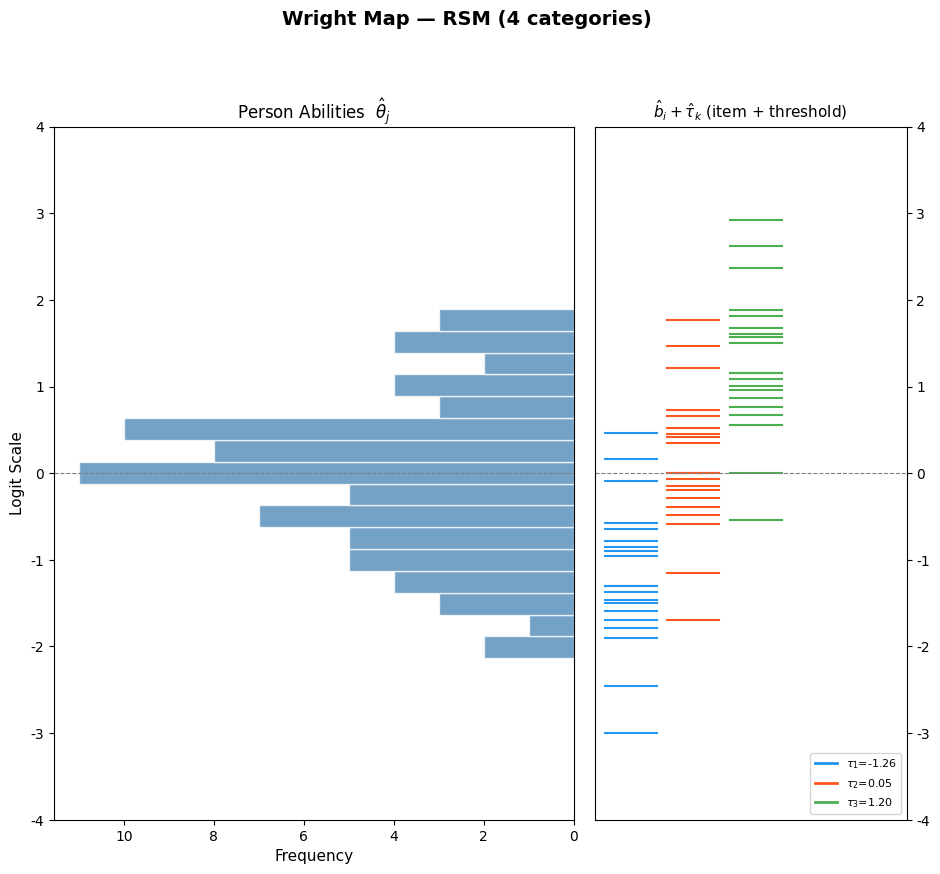

In [6]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
step_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

for i in range(I):
    for k in range(K - 1):
        thresh_loc = b_est[i] + tau_est[k]
        ax_i.plot([0.05 + k * 0.3, 0.3 + k * 0.3], [thresh_loc, thresh_loc],
                  color=step_colors[k], linewidth=1.5)

ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('$\\hat{b}_i + \\hat{\\tau}_k$ (item + threshold)', fontsize=11)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=step_colors[k], linewidth=2, label=f'$\\tau_{k+1}$={tau_est[k]:.2f}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — RSM (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_rsm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC)

$$P(X_i = k \mid \theta) \propto \exp\!\left(k(\theta - \hat{b}_i) - \sum_{m=1}^{k} \hat{\tau}_m\right)$$

**Interpretation**: All items' category curves have the **same shape** — they are simply horizontal translations of each other determined by $b_i$. Easy items (low $b_i$) have their curves shifted left; hard items are shifted right. This uniformity is both the strength and the major assumption of the RSM.

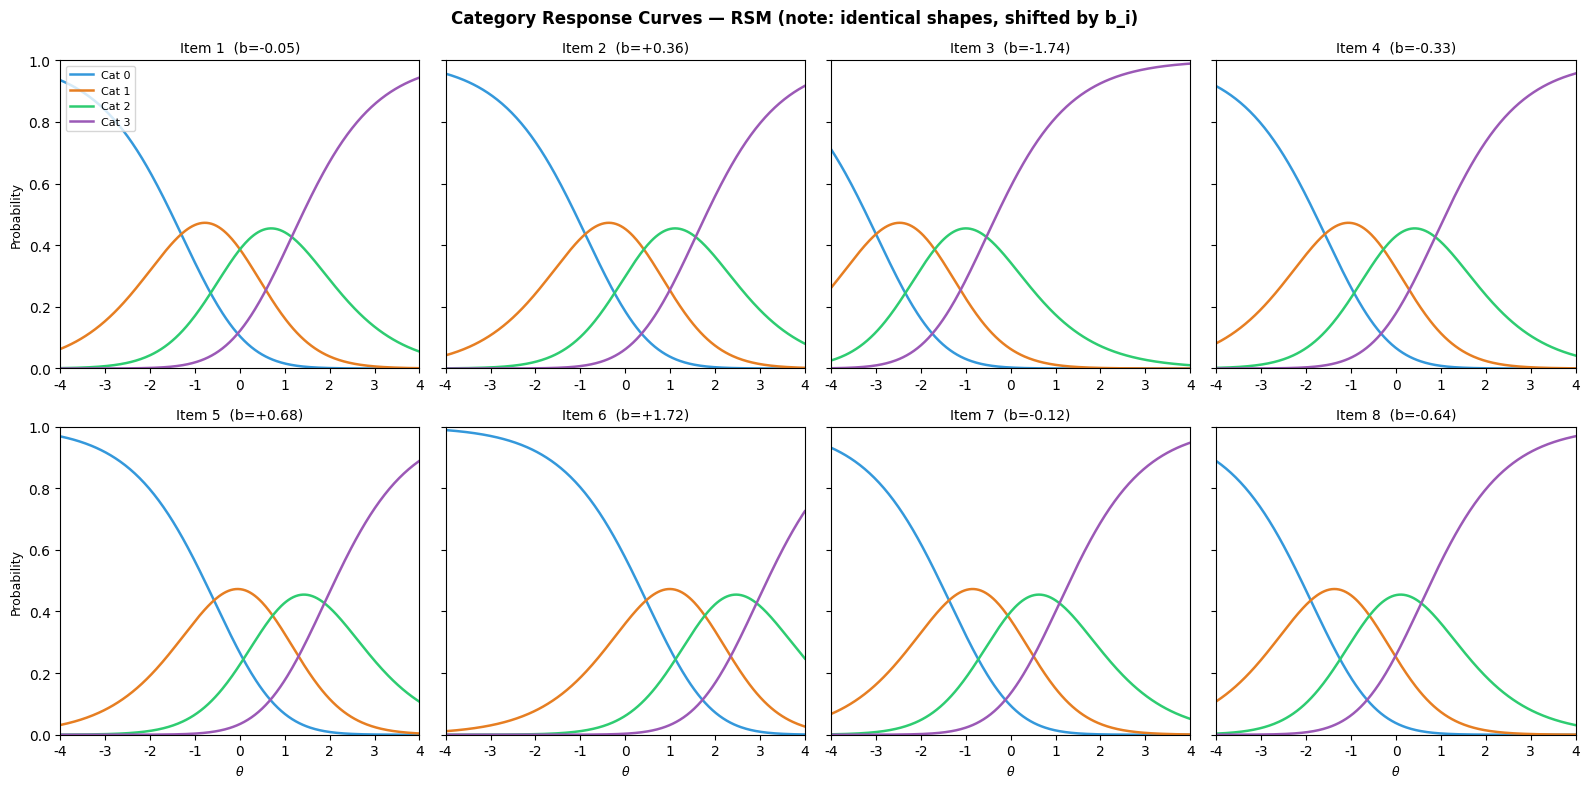

In [7]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [rsm_probs(t, b_est[i], tau_est)[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8, label=f'Cat {k}')
    ax.set_title(f'Item {i+1}  (b={b_est[i]:+.2f})', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('Category Response Curves — RSM (note: identical shapes, shifted by b_i)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_rsm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

$$\text{TCC}(\theta) = \sum_{i=1}^{I} \sum_{k=0}^{K-1} k \cdot P(X_i = k \mid \theta)$$

**Interpretation**: Because items all have the same category spacing, the TCC rises smoothly with fewer irregularities than a PCM with heterogeneous thresholds. Items spread across a range of $b_i$ values give the TCC a broad, informative region. A narrow spread of $b_i$ values would create a steep sigmoid-like TCC with less precision near the extremes.

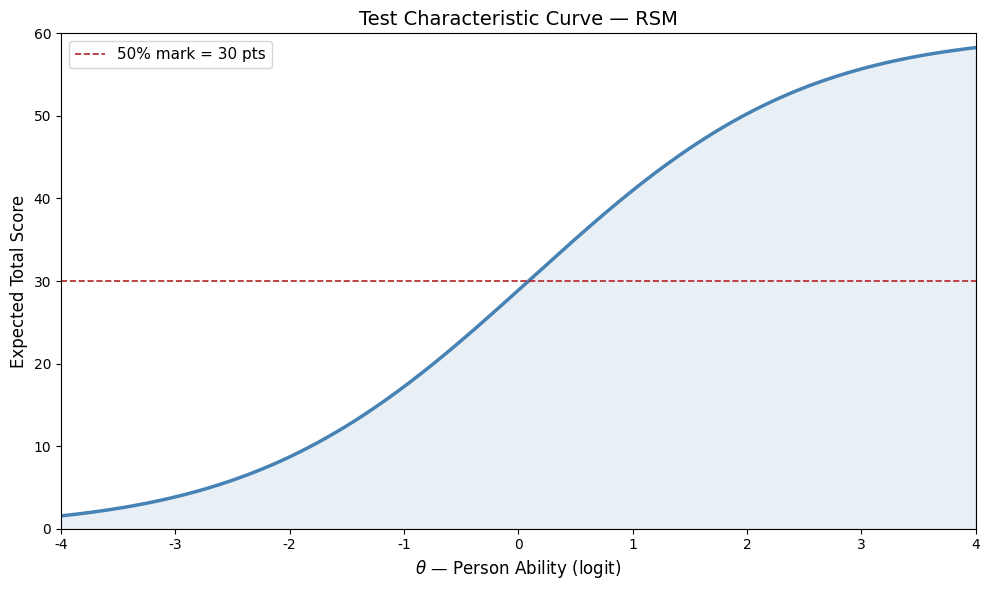

In [8]:
expected_score = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = rsm_probs(t, b_est[i], tau_est)
        expected_score[t_idx] += np.dot(np.arange(K), pr)

max_score = I * (K - 1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, expected_score, color='steelblue', linewidth=2.5)
ax.fill_between(theta_range, 0, expected_score, alpha=0.12, color='steelblue')
ax.axhline(max_score / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% mark = {max_score//2} pts')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected Total Score', fontsize=12)
ax.set_title('Test Characteristic Curve — RSM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, max_score); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_rsm.png'), dpi=120, bbox_inches='tight')
plt.show()

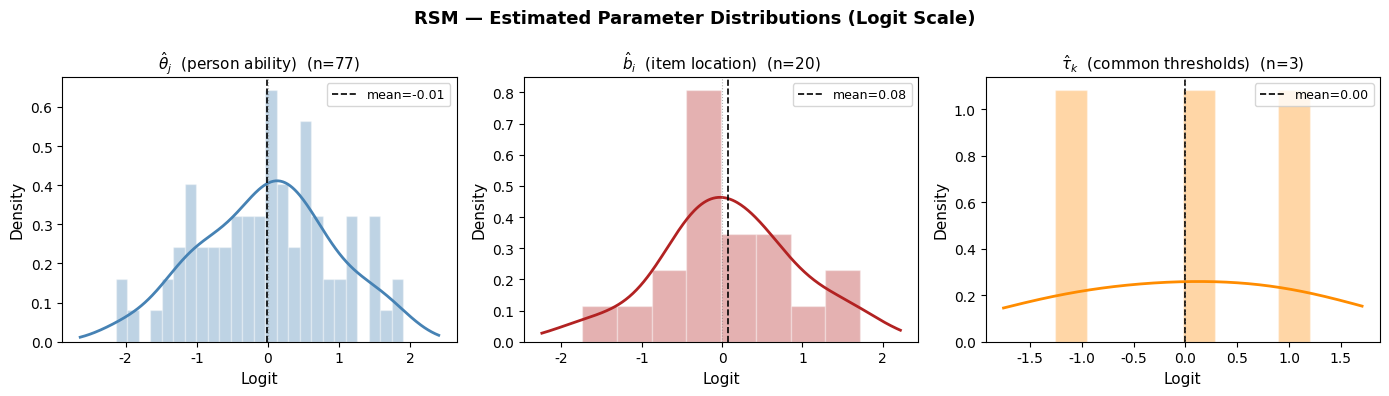

theta: mean=-0.012  SD=0.921  range=[-2.14, 1.90]
b    : mean=0.079  SD=0.814  range=[-1.74, 1.72]
tau  : mean=0.000  SD=1.005  range=[-1.26, 1.20]


In [9]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('RSM — Estimated Parameter Distributions (Logit Scale)', fontsize=13, fontweight='bold')

panels = [
    (axes[0], theta_est, r'$\hat{\theta}_j$  (person ability)',    'steelblue'),
    (axes[1], b_est,     r'$\hat{b}_i$  (item location)',           'firebrick'),
    (axes[2], tau_est,   r'$\hat{\tau}_k$  (common thresholds)',   'darkorange'),
]

for ax, vals, title, color in panels:
    ax.hist(vals, bins=max(8, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Logit', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_rsm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('b', b_est), ('tau', tau_est)]:
    print(f"{name:5s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
